# Importing and installing all the libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('archive/games.csv')
df.head()


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  str    
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  str    
 6   winner          20058 non-null  str    
 7   increment_code  20058 non-null  str    
 8   white_id        20058 non-null  str    
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  str    
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  str    
 13  opening_eco     20058 non-null  str    
 14  opening_name    20058 non-null  str    
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), str(9)
memory usage: 2.3 MB


In [5]:
# Checking for null values
df.isnull().sum()

id                0
rated             0
created_at        0
last_move_at      0
turns             0
victory_status    0
winner            0
increment_code    0
white_id          0
white_rating      0
black_id          0
black_rating      0
moves             0
opening_eco       0
opening_name      0
opening_ply       0
dtype: int64

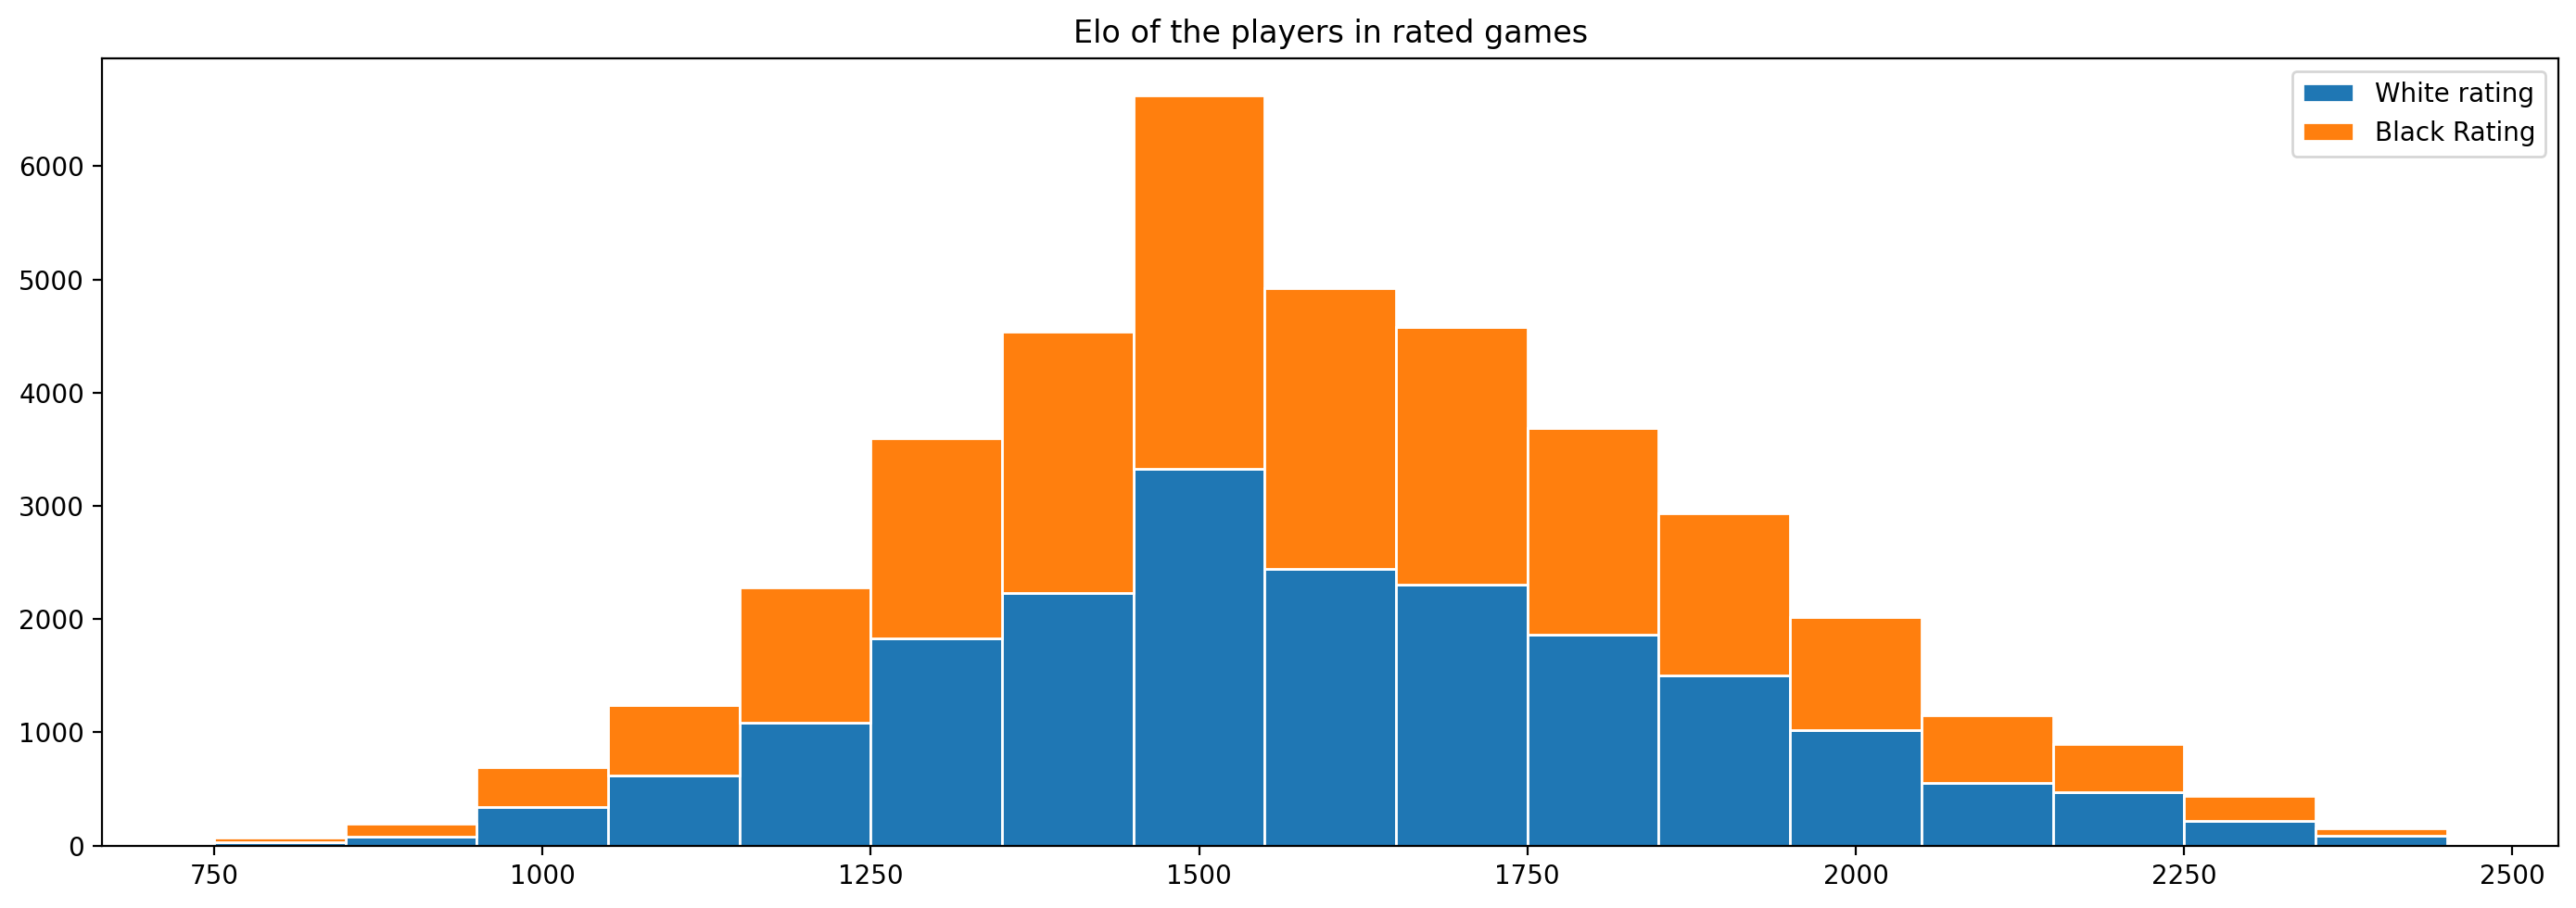

In [20]:
# Plotting the ELO of the players in games

plt.figure(figsize =(14, 5), dpi=200)
plt.title("Elo of the players in rated games")
plt.hist([df.white_rating, df.black_rating], 
         stacked=True,edgecolor='white', bins= np.arange(750, 2500, 100))
plt.legend(["White rating", "Black Rating"])
plt.tight_layout();

1477


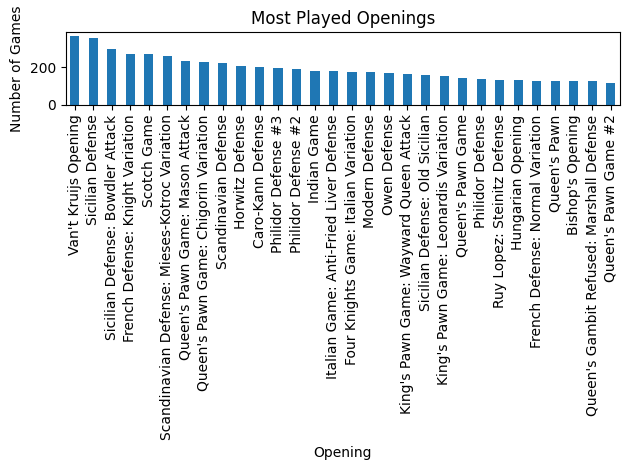

In [7]:
opening_counts = df["opening_name"].value_counts()
c=0
for i in range(len(opening_counts)):
    c+=1
print(c)
# filtered = opening_stats.loc[popular_openings]
top_openings = opening_counts.head(30)

plt.figure()
top_openings.plot(kind="bar")

plt.title("Most Played Openings")
plt.xlabel("Opening")
plt.ylabel("Number of Games")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [8]:
# Combine both players' Elo into one column
all_elo = pd.concat([df["white_rating"], df["black_rating"]])

# Create bins of size 100
bins = range(800, int(all_elo.max()) + 200, 200)

# Categorize Elo into bins
elo_groups = pd.cut(all_elo, bins=bins)

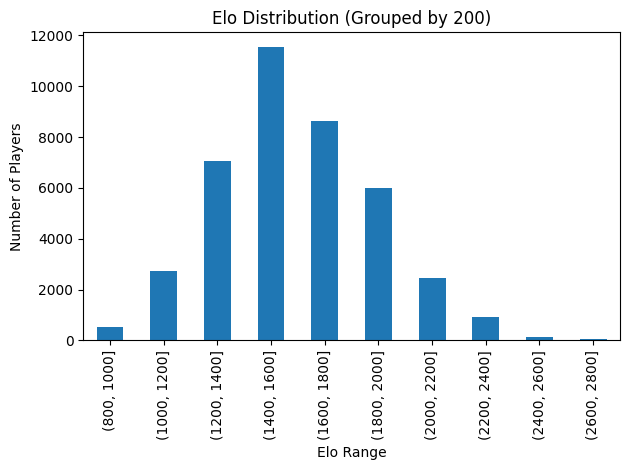

In [9]:
elo_counts = elo_groups.value_counts().sort_index()
import matplotlib.pyplot as plt

plt.figure()
elo_counts.plot(kind="bar")

plt.title("Elo Distribution (Grouped by 200)")
plt.xlabel("Elo Range")
plt.ylabel("Number of Players")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

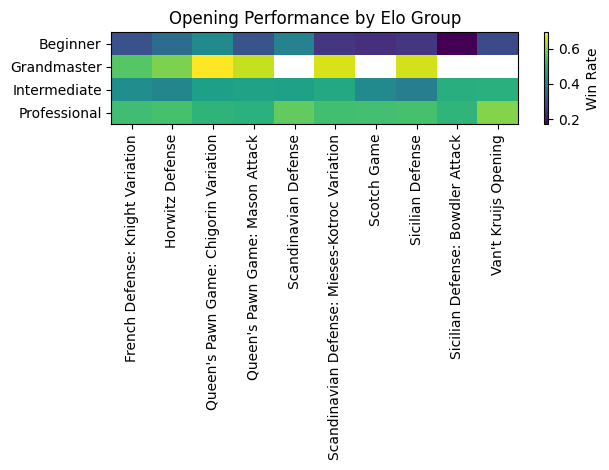

In [10]:
def elo_group(elo):
    if elo < 1200:
        return "Beginner"
    elif elo < 1400:
        return "Intermediate"
    elif elo < 1600:
        return "Professional"
    elif elo < 1800:
        return "Professional"
    elif elo < 2000:
        return "Professional"
    else:
        return "Grandmaster"
# White perspective
white_df = df.copy()
white_df["PlayerElo"] = white_df["white_rating"]
white_df["PlayerScore"] = white_df["winner"].apply(
    lambda x: 1 if x == "white" else 0 if x == "black" else 0.5
)

# Black perspective
black_df = df.copy()
black_df["PlayerElo"] = black_df["black_rating"]
black_df["PlayerScore"] = black_df["winner"].apply(
    lambda x: 1 if x == "black" else 0 if x == "white" else 0.5
)

# Combine
combined = pd.concat([white_df, black_df])

combined["EloGroup"] = combined["PlayerElo"].apply(elo_group)
top_openings = combined["opening_name"].value_counts().head(10).index
filtered = combined[combined["opening_name"].isin(top_openings)]
grouped = filtered.groupby(["EloGroup", "opening_name"])["PlayerScore"].mean().unstack()
counts = filtered.groupby(["EloGroup", "opening_name"]).size().unstack()

grouped = grouped.where(counts >= 20)

import matplotlib.pyplot as plt

plt.figure()
plt.imshow(grouped, aspect="auto")

plt.colorbar(label="Win Rate")

plt.xticks(range(len(grouped.columns)), grouped.columns, rotation=90)
plt.yticks(range(len(grouped.index)), grouped.index)

plt.title("Opening Performance by Elo Group")

plt.tight_layout()
plt.show()

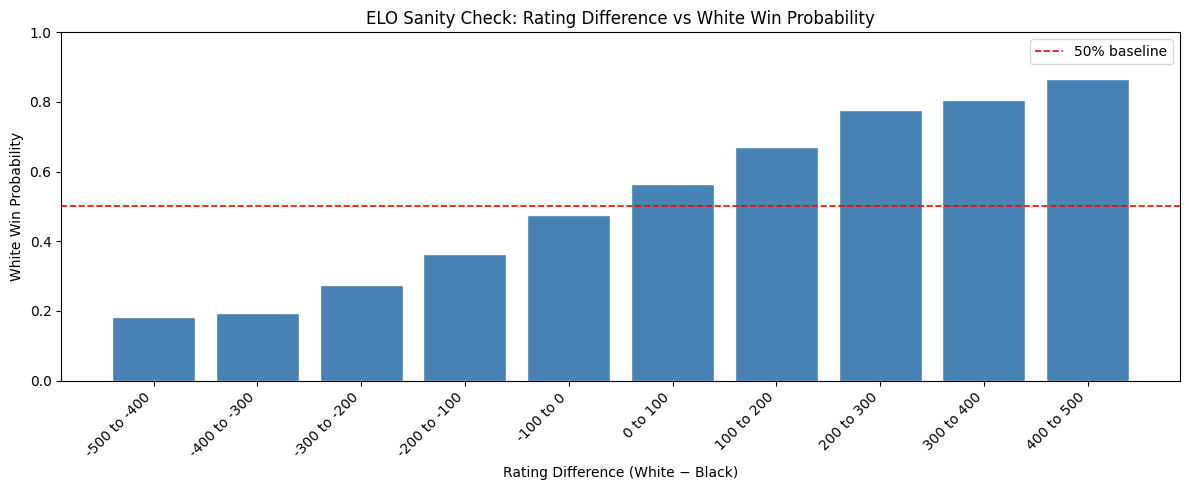

In [11]:

# --- derived columns ---
df['rating_diff'] = df['white_rating'] - df['black_rating']
df['white_win']   = (df['winner'] == 'white').astype(int)

# bin rating difference into brackets of 100
bins   = range(-500, 600, 100)
labels = [f"{b}" for b in range(-500, 500, 100)]
df['diff_bin'] = pd.cut(df['rating_diff'], bins=bins, labels=labels)

# win probability per bin (exclude draws)
no_draws = df[df['winner'] != 'draw']
win_prob = no_draws.groupby('diff_bin', observed=True)['white_win'].mean()

# --- plot ---
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(range(len(win_prob)), win_prob.values, color='steelblue', edgecolor='white')
ax.axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='50% baseline')

ax.set_xticks(range(len(win_prob)))
ax.set_xticklabels([f"{l} to {int(l)+100}" for l in win_prob.index], rotation=45, ha='right')
ax.set_xlabel("Rating Difference (White − Black)")
ax.set_ylabel("White Win Probability")
ax.set_title("ELO Sanity Check: Rating Difference vs White Win Probability")
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()

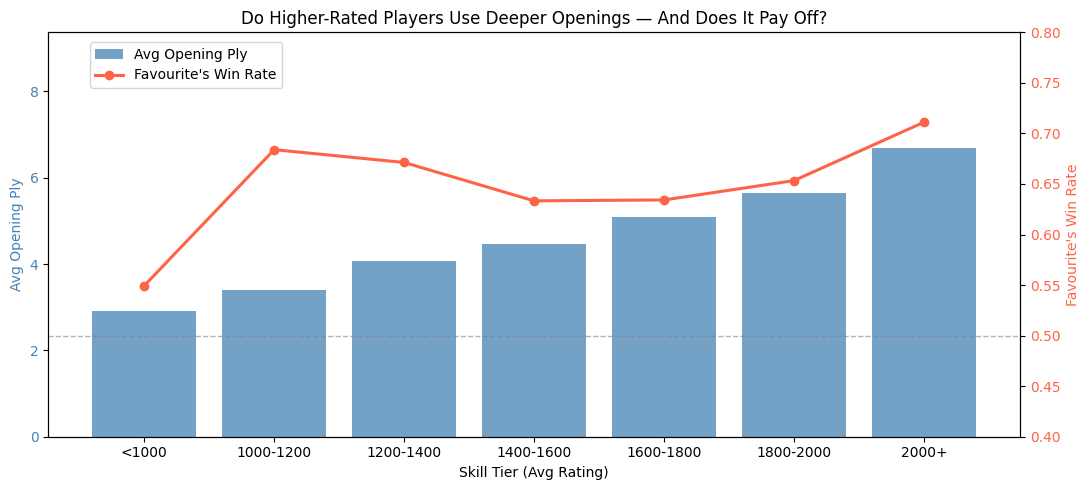

In [12]:
# --- setup ---
df['avg_rating']    = (df['white_rating'] + df['black_rating']) / 2
df['opening_ply']   = pd.to_numeric(df['opening_ply'], errors='coerce')

# who is the favourite, and did they win?
df['fav_is_white']  = df['white_rating'] >= df['black_rating']
df['fav_won']       = (
    ((df['fav_is_white']) & (df['winner'] == 'white')) |
    ((~df['fav_is_white']) & (df['winner'] == 'black'))
)

# bin by avg rating into skill tiers
tier_bins   = [0, 1000, 1200, 1400, 1600, 1800, 2000, 9999]
tier_labels = ['<1000', '1000-1200', '1200-1400', '1400-1600',
               '1600-1800', '1800-2000', '2000+']
df['tier'] = pd.cut(df['avg_rating'], bins=tier_bins, labels=tier_labels)

# aggregate (exclude draws for win rate)
no_draws = df[df['winner'] != 'draw']
agg = no_draws.groupby('tier', observed=True).agg(
    avg_ply  = ('opening_ply', 'mean'),
    win_rate = ('fav_won',     'mean')
).reset_index()

# --- plot ---
fig, ax1 = plt.subplots(figsize=(11, 5))

# bars — avg opening_ply
ax1.bar(agg['tier'], agg['avg_ply'], color='steelblue',
        alpha=0.75, label='Avg Opening Ply')
ax1.set_xlabel('Skill Tier (Avg Rating)')
ax1.set_ylabel('Avg Opening Ply', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim(0, agg['avg_ply'].max() * 1.4)

# line — favourite's win rate
ax2 = ax1.twinx()
ax2.plot(agg['tier'], agg['win_rate'], color='tomato',
         marker='o', linewidth=2.2, label="Favourite's Win Rate")
ax2.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax2.set_ylabel("Favourite's Win Rate", color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
ax2.set_ylim(0.4, 0.8)

plt.title("Do Higher-Rated Players Use Deeper Openings — And Does It Pay Off?")
fig.legend(loc='upper left', bbox_to_anchor=(0.08, 0.92))
plt.tight_layout()
plt.show()

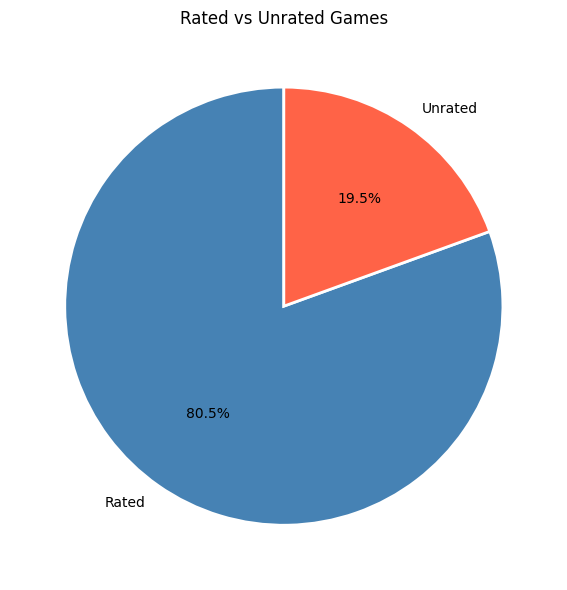

In [13]:
rated_counts = df['rated'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    rated_counts,
    labels=['Rated', 'Unrated'],
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Rated vs Unrated Games')
plt.tight_layout()
plt.show()

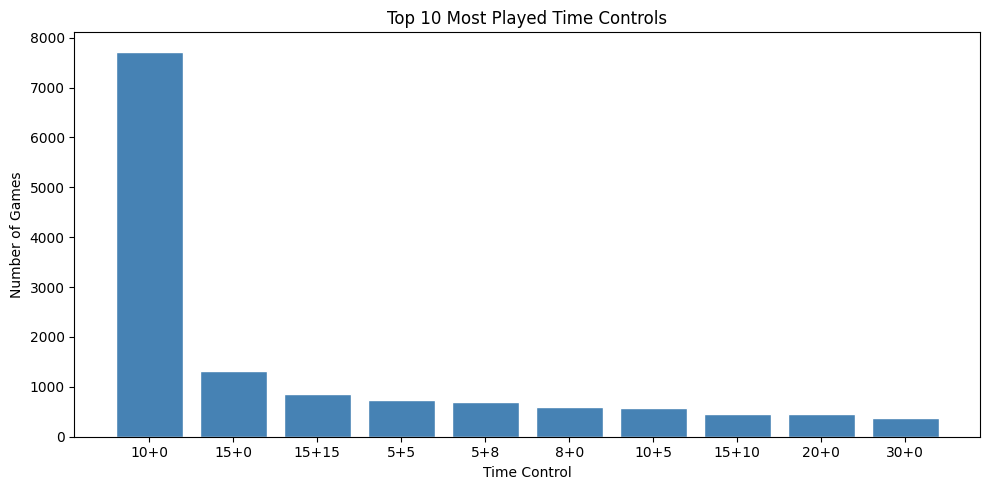

In [14]:
top_tc = df['increment_code'].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_tc.index, top_tc.values, color='steelblue', edgecolor='white')
plt.xlabel('Time Control')
plt.ylabel('Number of Games')
plt.title('Top 10 Most Played Time Controls')
plt.tight_layout()
plt.show()

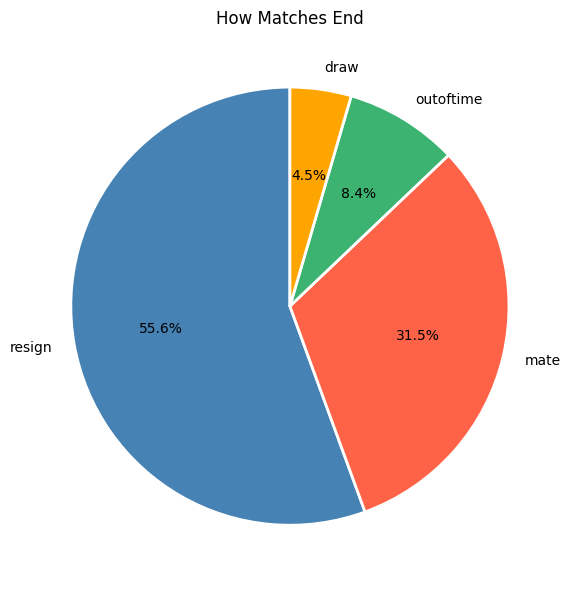

In [15]:
vs_counts = df['victory_status'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    vs_counts,
    labels=vs_counts.index,
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato', 'mediumseagreen', 'orange'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('How Matches End')
plt.tight_layout()
plt.show()

<Figure size 600x600 with 0 Axes>

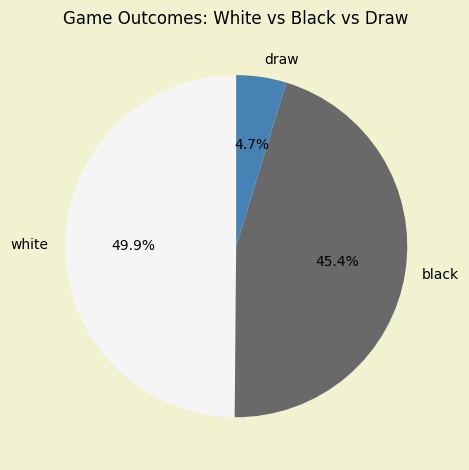

In [16]:
winner_counts = df['winner'].value_counts()

plt.figure(figsize=(6, 6))
fig, ax = plt.subplots(facecolor="#F2F2D1")

plt.pie(
    winner_counts,
    labels=winner_counts.index,
    autopct='%1.1f%%',
    colors=['whitesmoke', 'dimgray', 'steelblue'],
    startangle=90,
    wedgeprops={'linewidth': 2}
)
plt.title('Game Outcomes: White vs Black vs Draw')
plt.tight_layout()
plt.show()

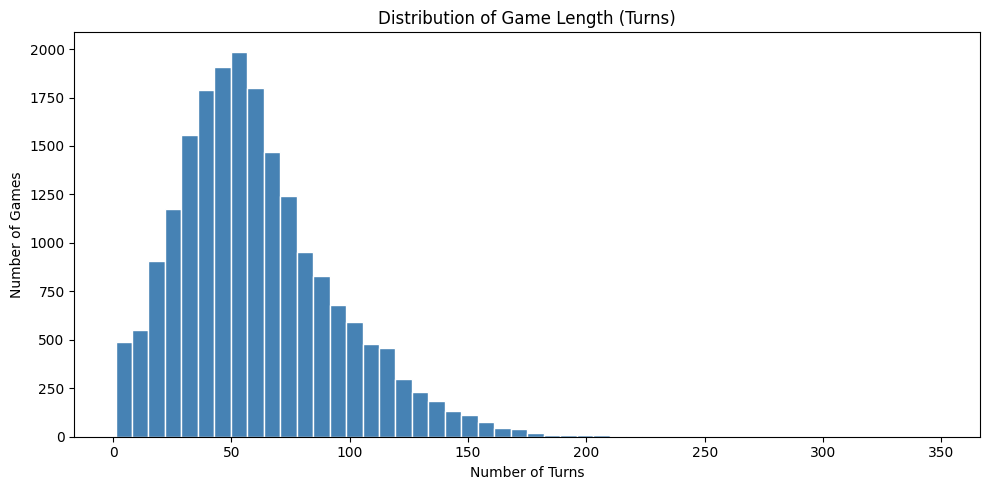

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(df['turns'], bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Number of Turns')
plt.ylabel('Number of Games')
plt.title('Distribution of Game Length (Turns)')
plt.tight_layout()
plt.show()

# Conclusion
With this Exploratory Data Analysis, we can conclude a few things using the graphs made in this project.

Of all the games played, 80.5% were Rated games, while the other 19.5% were Unrated.
The ELO (rating) of the players in the dataset appears to be mainly between the 1450 to 11800 range.
Most games have a number of turns ranging from 40 to 60.
Of the 16.155 rated games, black won 7384 (45.7%), white won 8052 (49.8%) and 719 were draws (4.5%).
The openings used in the games of this dataset are varied, although the most used one was the Van't Kruijs Opening, where white begins with 1. e3; followed by the Sicilian Defense, where white starts with 1.e4 and black responds with c5, preventing white from taking the whole centre with d4.
Although Van't Kruijs Opening was the most played, I believe that is because it is only one move (with no variations included in the opening name itself), where openings start with 1. e4 or 1. d4 and usually have different lines.
Of the time controls used, 10+0 (10 minutes without increments) was the most played with 6.817 plays, being a "Rapid" time control.
When it comes to how the match ends, 8.969 games ended with the opponent resigning (55.5%), 5.146 ended with a checkmate (31.9%), 1.359 ended by flagging (running out of time)(8.4%), and 681 were draws (4.2%).
Overall, I believe this project helps understand some of the statistics of chess.

# Refrences
- Matplotlib Documentation
- NumPy Documentation
- Pandas Documentation
- Seaborn Documentation
- Plot a pie chart in Python using Matplotlib
- Chess Games Dataset (Lichess)